In [1]:
!nvidia-smi
!pip install ultralytics onnx onnxruntime opencv-python pyyaml
!git clone https://github.com/ak-asu/brailleapp.git braille
%cd braille

Mon Jun  1 03:46:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   36C    P0             55W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
%%writefile braille_dots.yaml
path: /content/braille/data/braille_dots
train: images/train
val: images/val
nc: 1
names: ['dot']

Writing braille_dots.yaml


In [6]:
%cd /content
!git clone https://github.com/yeluo1994/DSBI.git
!git clone https://github.com/IlyaOvodov/AngelinaDataset.git

/content
Cloning into 'DSBI'...
remote: Enumerating objects: 586, done.
remote: Total 586 (delta 0), reused 0 (delta 0), pack-reused 586 (from 1)
Receiving objects: 100% (586/586), 272.33 MiB | 18.65 MiB/s, done.
Resolving deltas: 100% (51/51), done.
Cloning into 'AngelinaDataset'...
remote: Enumerating objects: 1064, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 1064 (delta 15), reused 14 (delta 14), pack-reused 1034 (from 1)
Receiving objects: 100% (1064/1064), 47.35 MiB | 18.63 MiB/s, done.
Resolving deltas: 100% (335/335), done.


### Next Step: Data Conversion
The datasets downloaded above are not natively in YOLO format. Before running the YOLO training cell, we need to create a conversion script to parse their annotations (e.g., XML or custom formats) and output YOLO `.txt` label files containing:

`0 cx cy w h`

*(where `0` is the class ID for 'dot', and `cx, cy, w, h` are normalized bounding box coordinates).* Once converted, the images and labels must be placed into `/content/braille/data/braille_dots/images` and `labels` respectively.

In [7]:
import os

base_dir = '/content/braille/data/braille_dots'
for split in ['train', 'val']:
    os.makedirs(f'{base_dir}/images/{split}', exist_ok=True)
    os.makedirs(f'{base_dir}/labels/{split}', exist_ok=True)
print('Directories created.')

print('DSBI files:', os.listdir('/content/DSBI'))
print('AngelinaDataset files:', os.listdir('/content/AngelinaDataset'))

Directories created.
DSBI files: ['data', 'README.md', 'train.txt', 'figures', 'test.txt', '.git']
AngelinaDataset files: ['README.md', 'pics', 'src', 'uploaded', '.gitignore', 'books', '.git', 'not_braille', 'handwritten']


In [9]:
import os
import glob

print("=== DSBI Dataset ===")
dsbi_data_path = '/content/DSBI/data'
if os.path.exists(dsbi_data_path):
    sample_txt = glob.glob(os.path.join(dsbi_data_path, '*.txt'))
    if sample_txt:
        print(f"Found DSBI annotation: {os.path.basename(sample_txt[0])}")
        with open(sample_txt[0], 'r') as f:
            print(f.read()[:400])
    else:
        print("No .txt files found. Extensions present:", set([os.path.splitext(f)[1] for f in os.listdir(dsbi_data_path)]))

print("\n=== Angelina Dataset ===")
for folder in ['uploaded', 'pics', 'handwritten']:
    path = f'/content/AngelinaDataset/{folder}'
    if os.path.exists(path):
        annos = glob.glob(os.path.join(path, '*.json')) + glob.glob(os.path.join(path, '*.txt'))
        if annos:
            print(f"Found Angelina annotation in {folder}: {os.path.basename(annos[0])}")
            with open(annos[0], 'r') as f:
                print(f.read()[:500])
            break

=== DSBI Dataset ===
No .txt files found. Extensions present: {''}

=== Angelina Dataset ===
Found Angelina annotation in uploaded: test.txt
test2/16208199091213172220599072788385.labeled.jpg
test2/image_893.labeled.jpg
test2/16149297430347959904043812835237.labeled.jpg
test2/16133680849224939776977609910946.labeled.jpg
test2/image_1104.labeled.jpg
test2/16158293792985296089064141415508.labeled.jpg
test2/16212558309825739935733992080657.labeled.jpg
test2/image_757.labeled.jpg
test2/16176160088617889824558606265568.labeled.jpg
test2/16175620075383318290172083202563.labeled.jpg
test2/WhatsApp_Image_2021-02-03_at_15.28.58.labeled.jpg
te


In [10]:
import os

print("=== Deep DSBI Search ===")
for root, dirs, files in os.walk('/content/DSBI'):
    for f in files:
        if f.endswith(('.json', '.xml', '.csv', '.txt')) and f not in ['train.txt', 'test.txt', 'README.md']:
            print(f"Found DSBI annotation: {os.path.join(root, f)}")
            with open(os.path.join(root, f), 'r') as file:
                print(file.read()[:400])
            break
    else:
        continue
    break

print("\n=== Deep Angelina Search ===")
for root, dirs, files in os.walk('/content/AngelinaDataset'):
    for f in files:
        if f.endswith('.json') and 'not_braille' not in root:
            print(f"Found Angelina annotation: {os.path.join(root, f)}")
            with open(os.path.join(root, f), 'r') as file:
                print(file.read()[:400])
            break
    else:
        continue
    break

=== Deep DSBI Search ===
Found DSBI annotation: /content/DSBI/data/Ordinary Printed Document/OPD+2+verso.txt
0.10
43 63 90 110 137 155 182 202 224 246 275 292 320 339 367 387 416 435 462 482 509 530 558 577 605 623 650 670 698 718 745 766 793 812 840 860 887 907 934 955 982 1002 1028 1046 1074 1094 1122 1142 1170 1189 1217 1237 1265 1284 1312 1331 1359 1380 1408 1429 1456 1475 1503 1523 1550 1571 1599 1618 1646 1665
33 52 71 111 130 149 187 206 224 262 282 301 341 360 379 419 438 458 497 517 536 575 594 

=== Deep Angelina Search ===
Found Angelina annotation: /content/AngelinaDataset/uploaded/test2/1613636025206..labeled.json
{
  "version": "3.16.1",
  "flags": {},
  "shapes": [
    {
      "label": "##",
      "line_color": null,
      "fill_color": null,
      "points": [
        [
          910.2546373176575,
          62.701660079956056
        ],
        [
          927.91760389328,
          95.38472520828248
        ]
      ],
      "shape_type": "rectangle",
      "flags": {}


In [11]:
import os
import glob
import json
import shutil
import cv2
from sklearn.model_selection import train_test_split

# Setup paths
base_dir = '/content/braille/data/braille_dots'
os.makedirs(f'{base_dir}/images/train', exist_ok=True)
os.makedirs(f'{base_dir}/images/val', exist_ok=True)
os.makedirs(f'{base_dir}/labels/train', exist_ok=True)
os.makedirs(f'{base_dir}/labels/val', exist_ok=True)

# Find all Angelina JSON annotations
angelina_jsons = glob.glob('/content/AngelinaDataset/**/*.json', recursive=True)
valid_data = []

for j_path in angelina_jsons:
    if 'not_braille' in j_path:
        continue

    # Check if corresponding image exists
    img_path = j_path.replace('.labeled.json', '.labeled.jpg')
    if not os.path.exists(img_path):
        img_path = j_path.replace('.json', '.jpg')
        if not os.path.exists(img_path):
            continue

    with open(j_path, 'r') as f:
        try:
            data = json.load(f)
            valid_data.append((j_path, img_path, data))
        except json.JSONDecodeError:
            continue

# Split into 80% train, 20% val
train_data, val_data = train_test_split(valid_data, test_size=0.2, random_state=42)

def process_split(split_data, split_name):
    count = 0
    for j_path, img_path, data in split_data:
        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w, _ = img.shape
        if h == 0 or w == 0:
            continue

        base_name = os.path.basename(img_path).rsplit('.', 1)[0]
        label_path = os.path.join(base_dir, 'labels', split_name, f"{base_name}.txt")
        new_img_path = os.path.join(base_dir, 'images', split_name, f"{base_name}.jpg")

        with open(label_path, 'w') as lf:
            for shape in data.get('shapes', []):
                if shape.get('shape_type') == 'rectangle':
                    pts = shape['points']
                    x1, y1 = pts[0]
                    x2, y2 = pts[1]

                    # Ensure min/max correctness
                    xmin, xmax = min(x1, x2), max(x1, x2)
                    ymin, ymax = min(y1, y2), max(y1, y2)

                    # Calculate normalized YOLO format
                    cx = ((xmin + xmax) / 2.0) / w
                    cy = ((ymin + ymax) / 2.0) / h
                    bw = (xmax - xmin) / w
                    bh = (ymax - ymin) / h

                    # Clip values safely between 0.0 and 1.0
                    cx, cy = max(0.0, min(1.0, cx)), max(0.0, min(1.0, cy))
                    bw, bh = max(0.0, min(1.0, bw)), max(0.0, min(1.0, bh))

                    # Class 0 for braille object
                    lf.write(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

        shutil.copy(img_path, new_img_path)
        count += 1
    return count

print(f"Found {len(valid_data)} valid image-annotation pairs in Angelina Dataset.")
print("Converting and copying files...")
train_count = process_split(train_data, 'train')
val_count = process_split(val_data, 'val')

print(f"Conversion complete! Successfully processed:")
print(f" - {train_count} training images")
print(f" - {val_count} validation images")
print("\nYou can now run the YOLO training cell!")

Found 290 valid image-annotation pairs in Angelina Dataset.
Converting and copying files...
Conversion complete! Successfully processed:
 - 232 training images
 - 58 validation images

You can now run the YOLO training cell!


In [13]:
!yolo train model=yolov8n.pt data=/content/braille/braille_dots.yaml epochs=100 imgsz=640 batch=16 degrees=30 hsv_v=0.4 perspective=0.001

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/braille/braille_dots.yaml, degrees=30, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

In [15]:
!yolo export model=/content/runs/detect/train-3/weights/best.pt format=onnx imgsz=640 opset=12
!mkdir -p models
!cp /content/runs/detect/train-3/weights/best.onnx models/yolov8n_braille.onnx

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train-3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 211ms
Prepared 2 packages in 26ms
Installed 2 packages in 7ms
 + colorama==0.4.6
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 2.0s, saved as '/content/runs/detect/

In [16]:
import onnxruntime as ort
import numpy as np

sess = ort.InferenceSession("/content/models/yolov8n_braille.onnx", providers=["CPUExecutionProvider"])
x = np.zeros((1, 3, 640, 640), dtype=np.float32)
y = sess.run(None, {sess.get_inputs()[0].name: x})
print("Output shape:", y[0].shape)

Output shape: (1, 5, 8400)


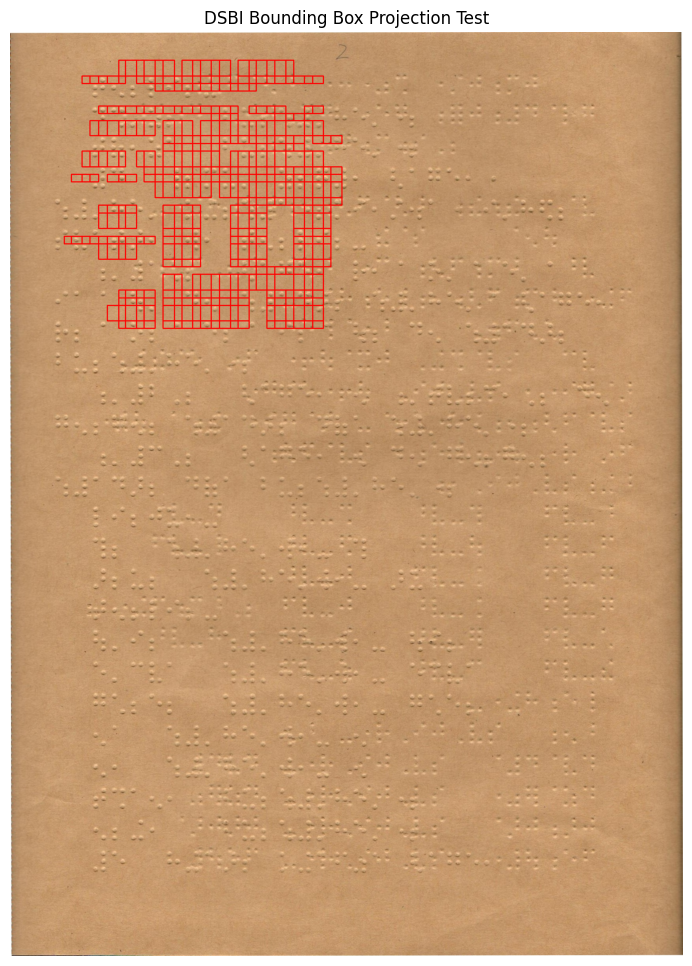

In [18]:
import os
import cv2
import matplotlib.pyplot as plt

sample_txt = '/content/DSBI/data/Ordinary Printed Document/OPD+2+verso.txt'
sample_img = sample_txt.replace('.txt', '.jpg')

with open(sample_txt, 'r') as f:
    lines = f.readlines()

# Line 1 is X coords, Line 2 is Y coords
x_coords = list(map(int, lines[1].strip().split()))
y_coords = list(map(int, lines[2].strip().split()))

img = cv2.imread(sample_img)
if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Plot boxes based on row/col indices
    for line in lines[3:]:
        parts = list(map(int, line.strip().split()))
        if len(parts) >= 8:
            r, c = parts[0], parts[1]
            try:
                # DSBI typically uses 0-based or 1-based indexing for the grid.
                # We will draw the rectangle from X[c] to X[c+1] and Y[r] to Y[r+1]
                x1 = x_coords[c]
                x2 = x_coords[c+1] if c+1 < len(x_coords) else x1 + 20
                y1 = y_coords[r]
                y2 = y_coords[r+1] if r+1 < len(y_coords) else y1 + 30

                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)
            except IndexError:
                pass

    plt.figure(figsize=(12, 12))
    plt.imshow(img_rgb)
    plt.title("DSBI Bounding Box Projection Test")
    plt.axis('off')
    plt.show()
else:
    print(f"Could not load image: {sample_img}\nCheck if the image file has a different extension (like .png or .jpeg)")

In [19]:
import os
import glob
import shutil
import cv2
from sklearn.model_selection import train_test_split

base_dir = '/content/braille/data/braille_dots'
dsbi_txts = glob.glob('/content/DSBI/data/**/*.txt', recursive=True)
valid_dsbi = []

for txt_path in dsbi_txts:
    img_path = txt_path.replace('.txt', '.jpg')
    if os.path.exists(img_path):
        valid_dsbi.append((txt_path, img_path))

# Split into 80% train, 20% val
train_dsbi, val_dsbi = train_test_split(valid_dsbi, test_size=0.2, random_state=42)

def process_dsbi(split_data, split_name):
    count = 0
    for txt_path, img_path in split_data:
        img = cv2.imread(img_path)
        if img is None: continue

        h, w, _ = img.shape
        if h == 0 or w == 0: continue

        # Add a prefix to avoid filename collisions with AngelinaDataset
        base_name = "dsbi_" + os.path.basename(img_path).rsplit('.', 1)[0]
        label_path = os.path.join(base_dir, 'labels', split_name, f"{base_name}.txt")
        new_img_path = os.path.join(base_dir, 'images', split_name, f"{base_name}.jpg")

        with open(txt_path, 'r') as f:
            lines = f.readlines()

        if len(lines) < 3: continue

        x_coords = list(map(int, lines[1].strip().split()))
        y_coords = list(map(int, lines[2].strip().split()))

        with open(label_path, 'w') as lf:
            for line in lines[3:]:
                parts = list(map(int, line.strip().split()))
                if len(parts) >= 8:
                    r, c = parts[0], parts[1]
                    try:
                        x1 = x_coords[c]
                        x2 = x_coords[c+1] if c+1 < len(x_coords) else x1 + 20
                        y1 = y_coords[r]
                        y2 = y_coords[r+1] if r+1 < len(y_coords) else y1 + 30

                        # Calculate normalized YOLO format
                        cx = ((x1 + x2) / 2.0) / w
                        cy = ((y1 + y2) / 2.0) / h
                        bw = (x2 - x1) / w
                        bh = (y2 - y1) / h

                        # Clip values safely between 0.0 and 1.0
                        cx, cy = max(0.0, min(1.0, cx)), max(0.0, min(1.0, cy))
                        bw, bh = max(0.0, min(1.0, bw)), max(0.0, min(1.0, bh))

                        lf.write(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")
                    except IndexError:
                        pass

        shutil.copy(img_path, new_img_path)
        count += 1
    return count

print(f"Found {len(valid_dsbi)} valid image-annotation pairs in DSBI Dataset.")
print("Converting and copying files...")
train_count = process_dsbi(train_dsbi, 'train')
val_count = process_dsbi(val_dsbi, 'val')

print(f"DSBI Conversion complete!")
print(f" - Added {train_count} training images")
print(f" - Added {val_count} validation images")
print("\nYou can now re-run the YOLO training cell!")

Found 228 valid image-annotation pairs in DSBI Dataset.
Converting and copying files...
DSBI Conversion complete!
 - Added 176 training images
 - Added 44 validation images

You can now re-run the YOLO training cell!


In [20]:
!yolo train model=yolov8n.pt data=/content/braille/braille_dots.yaml epochs=100 imgsz=640 batch=16 degrees=30 hsv_v=0.4 perspective=0.001

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/braille/braille_dots.yaml, degrees=30, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

### Export the Combined Model
Export the model trained on both datasets to ONNX format.

In [21]:
!yolo export model=/content/runs/detect/train-4/weights/best.pt format=onnx imgsz=640 opset=12
!cp /content/runs/detect/train-4/weights/best.onnx models/yolov8n_braille_combined.onnx

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train-4/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)

ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.2s, saved as '/content/runs/detect/train-4/weights/best.onnx' (11.7 MB)

Export complete (1.5s)
Results saved to /content/runs/detect/train-4/weights/best.onnx
Predict:         yolo predict task=detect model=/content/runs/detect/train-4/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/train-4/weights/best.onnx imgsz=640 data=/content/braille/braille_dots.yaml  
Visualize:       https://netron.app
💡 Learn more at https://docs.ultralytics.com/modes/export


### Run Inference
Let's test the newly trained model on a validation image and visualize the detected Braille dots.

Running inference on /content/braille/data/braille_dots/images/val/IMG_20190715_123336.labeled.jpg

image 1/1 /content/braille/data/braille_dots/images/val/IMG_20190715_123336.labeled.jpg: 640x480 202 dots, 70.0ms
Speed: 3.0ms preprocess, 70.0ms inference, 19.7ms postprocess per image at shape (1, 3, 640, 480)


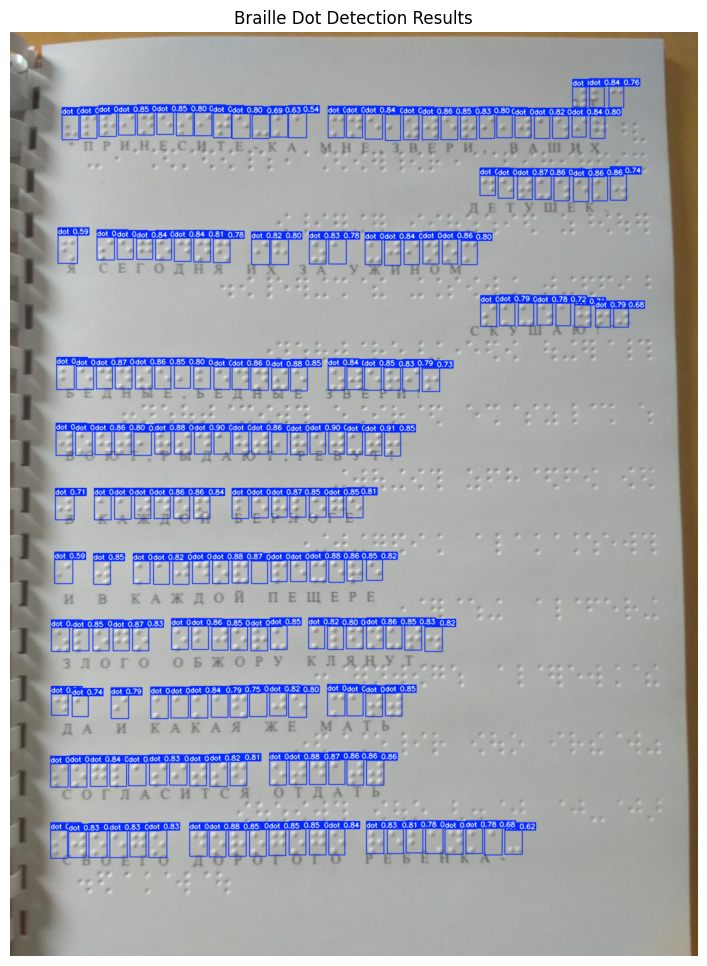

In [22]:
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load the newly trained model
model = YOLO('/content/runs/detect/train-4/weights/best.pt')

# Pick a test image from the validation set
test_images = glob.glob('/content/braille/data/braille_dots/images/val/*.jpg')
test_image_path = test_images[0] if test_images else None

if test_image_path:
    print(f"Running inference on {test_image_path}")
    # Run prediction
    results = model(test_image_path)

    # Plot the results
    res_plotted = results[0].plot(line_width=1)

    # Display using matplotlib
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Braille Dot Detection Results')
    plt.show()
else:
    print("No test images found in the validation directory.")

### Download Workspace
Compress all project files into a zip archive and download it.

In [23]:
import os
from google.colab import files

print("Zipping files... This may take a few minutes depending on the size of the datasets and models.")
# Zip the content directory, excluding the zip file itself and default Colab folders
!zip -r -q /content/workspace_archive.zip /content -x "/content/workspace_archive.zip" "/content/sample_data/*" "/content/.config/*"
print("Zip complete! Starting download...")

# Trigger the download in the browser
files.download('/content/workspace_archive.zip')

Zipping files... This may take a few minutes depending on the size of the datasets and models.
Zip complete! Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>